### Import libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data

In [46]:
column_names = ["checking_account_status", "duration_months", "credit_history", "purpose", "credit_amount",
                "savings_account", "employment_since", "installment_rate", "personal_status_sex", "other_debtors",
                "residence_since", "property", "age", "other_installment_plans", "housing",
                "existing_credits", "job", "num_liable_people", "telephone", "foreign_worker",
                "risk"
]
df = pd.read_csv("../data/raw/credit_data.data", sep=" ", header=None, names=column_names)
df.loc[df["risk"] == 1, "risk"] = 0
df.loc[df["risk"] == 2, "risk"] = 1

df.head()


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_liable_people,telephone,foreign_worker,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


### Basic Info

In [47]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account_status  1000 non-null   object
 1   duration_months          1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_since         1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,num_liable_people,risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


### Target Distribution

0    700
1    300
Name: risk, dtype: int64


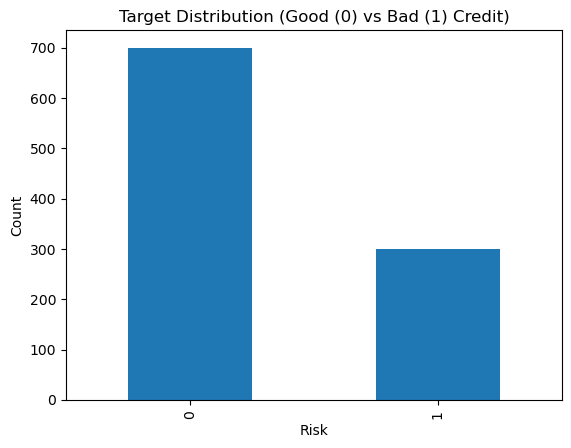

In [48]:
freq = df['risk'].value_counts()
print(freq)
freq.plot(kind='bar')
plt.title("Target Distribution (Good (0) vs Bad (1) Credit)")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.savefig("../reports/figures/risk_distribution.png")
plt.show()

The dataset seems to be imbalanced.

### Missing Values

In [49]:
df.isnull().sum()

checking_account_status    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_since           0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
num_liable_people          0
telephone                  0
foreign_worker             0
risk                       0
dtype: int64

No missing values found in the dataset.

### Numerical Feature Analysis

#### Age Distribution

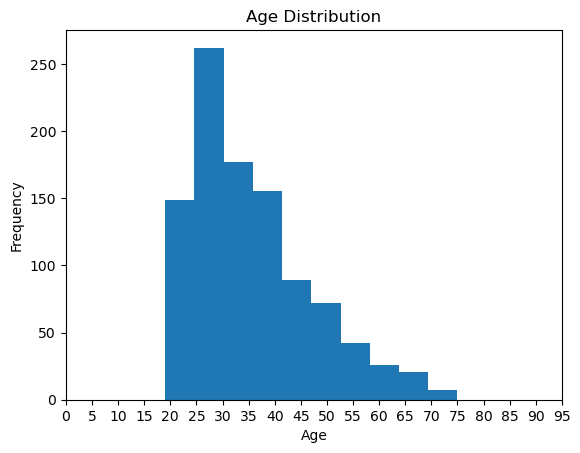

In [50]:
plt.hist(df['age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.xticks(range(0, 100, 5))
plt.ylabel("Frequency")
plt.savefig("../reports/figures/age_distribution.png")
plt.show()

Right skewed distribution  
The age of most of the people is around 20-40, i.e. young people tend to take credit more than old ones.

#### Credit Amount Distribution

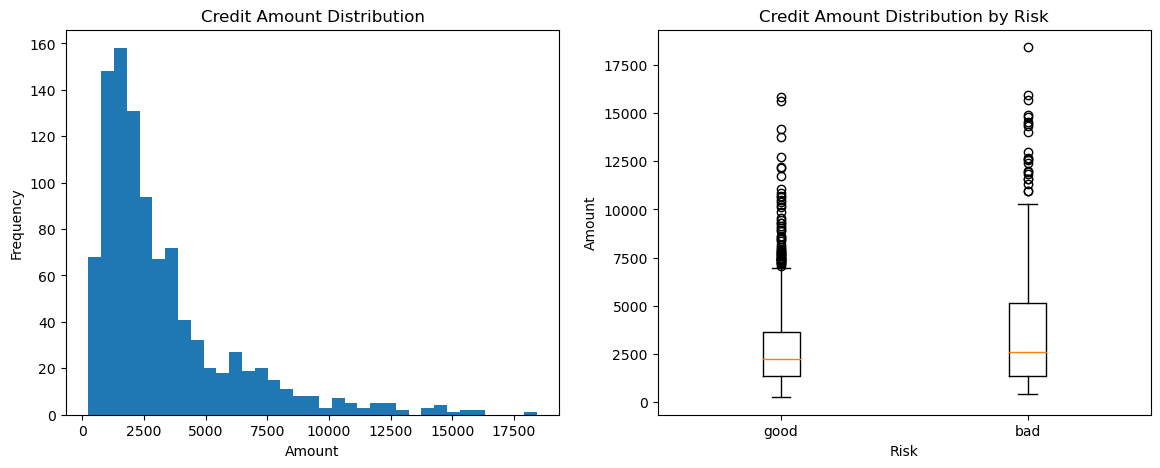

In [51]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['credit_amount'], bins='auto')
plt.title("Credit Amount Distribution")
plt.xlabel("Amount")
plt.xticks(range(0, 20000, 2500))
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.boxplot([df[df['risk'] == 0]['credit_amount'], df[df['risk'] == 1]['credit_amount']], labels=['good', 'bad'])
plt.title("Credit Amount Distribution by Risk")
plt.xlabel("Risk")
plt.ylabel("Amount")


plt.savefig("../reports/figures/credit_amount_distribution.png")
plt.show()


Right skewed distribution  
Most of the credit amounts are small  
Defaulters tend to take slightly higher credit amounts (but not significantly)

#### Duration Distribution

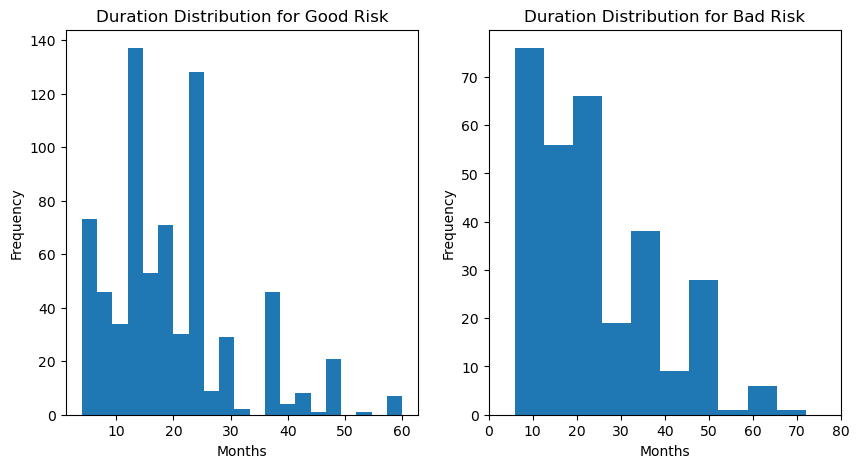

In [93]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(df[df['risk'] == 0]['duration_months'], bins='auto')
plt.title("Duration Distribution for Good Risk")
plt.xlabel("Months")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df[df['risk'] == 1]['duration_months'], bins='auto')
plt.title("Duration Distribution for Bad Risk")
plt.xlabel("Months")
plt.xticks(range(0, 90, 10))
plt.ylabel("Frequency")

# plt.subplot(1, 3, 3)
# plt.boxplot([df[df['risk'] == 1]['duration_months'], df[df['risk'] == 2]['duration_months']], labels=['good', 'bad'])
# plt.title("Duration Distribution by Risk")
# plt.xlabel("Risk")
# plt.ylabel("Months")


plt.savefig("../reports/figures/duration_distribution.png")
plt.show()

Longer duration seems to have higher risk of default.

### Default Rate by Category

#### Purpose vs Risk

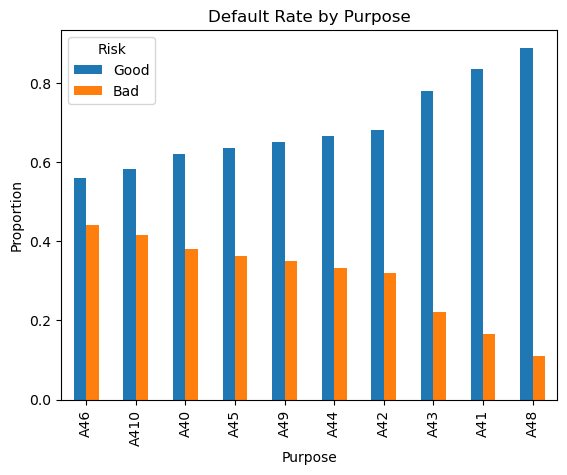

risk,0,1
purpose,,
A46,0.560000,0.440000
A410,0.583333,0.416667
A40,0.619658,0.380342
A45,0.636364,0.363636
A49,0.649485,0.350515
A44,0.666667,0.333333
A42,0.679558,0.320442
A43,0.778571,0.221429
A41,0.834951,0.165049


In [53]:
default_rate = pd.crosstab(df['purpose'], df['risk'], normalize='index')

default_rate = default_rate.sort_values(1, ascending=False, inplace=False)

default_rate.plot(kind='bar')
plt.title("Default Rate by Purpose")
plt.ylabel("Proportion")
plt.xlabel("Purpose")
plt.legend(title="Risk", labels=["Good", "Bad"])
plt.savefig("../reports/figures/default_rate_by_purpose.png")
plt.show()
display(default_rate)

The top 5 purposes with high default rates are: education, other, car (new), repairs, business

#### Housing vs Risk

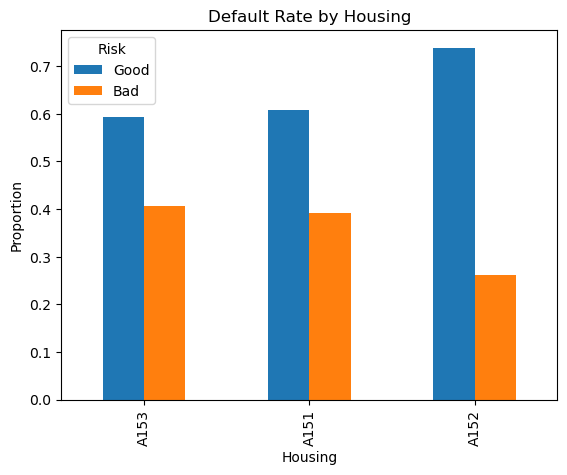

In [54]:
default_rate = pd.crosstab(df['housing'], df['risk'], normalize='index')
default_rate.sort_values(by=1, ascending=False, inplace=True)
default_rate.plot(kind='bar')
plt.title("Default Rate by Housing")
plt.ylabel("Proportion")
plt.xlabel("Housing")
plt.legend(title="Risk", labels=["Good", "Bad"])
plt.savefig("../reports/figures/default_rate_by_housing.png")
plt.show()

Almost 40% of the people who live for free (A153) are defaulters. Same is the case with those who have live on rent (A151).  
People who own their homes (A152) have the lowest default rate.

#### Saving Accounts vs Risk

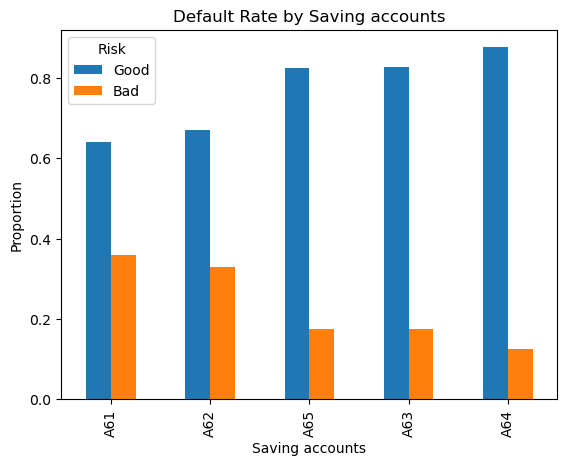

In [55]:
default_rate = pd.crosstab(df["savings_account"], df["risk"], normalize='index')
default_rate.sort_values(by=1, ascending=False, inplace=True)
default_rate.plot(kind='bar')
plt.title("Default Rate by Saving accounts")
plt.ylabel("Proportion")
plt.xlabel("Saving accounts")
plt.legend(title="Risk", labels=["Good", "Bad"])
plt.savefig("../reports/figures/default_rate_by_saving_accounts.png")
plt.show()

A61 implies < 100 DM, A62 implies 100-500 DM (DM = Deutsche Mark, German currency)  
Low amount of saving means high risk


#### Age vs Risk

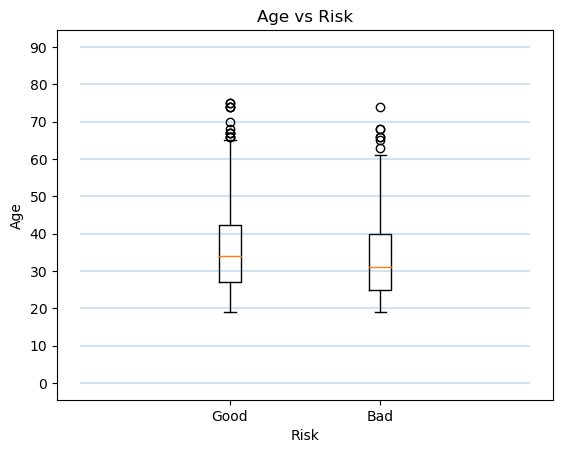

In [56]:
# df.boxplot(column="age", by="risk")
plt.boxplot([df[df["risk"] == 0]["age"], df[df["risk"] == 1]["age"]])
plt.title("Age vs Risk")
plt.yticks(range(0, 100, 10))
plt.hlines(range(0, 100, 10), 0, 3, alpha=0.2)
plt.xlabel("Risk")
plt.xticks([1, 2], ["Good", "Bad"])
plt.ylabel("Age")
plt.savefig("../reports/figures/age_vs_risk.png")
plt.show()

50% of non-defaulters are aged between 27 - 42  
50% of defaulters are aged between 24 - 40  
Defaulters are slightly younger than non-defaulters.

#### Telephone vs Risk

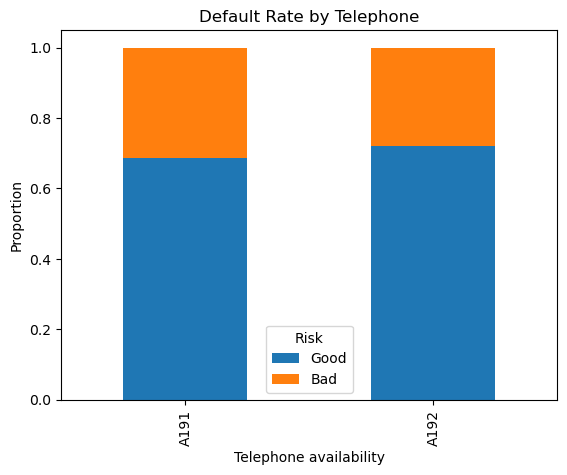

In [57]:
pd.crosstab(df['telephone'], df['risk'], normalize='index').plot(kind="bar", stacked=True)
plt.title("Default Rate by Telephone")
plt.ylabel("Proportion")
plt.xlabel("Telephone availability")
plt.legend(title="Risk", labels=["Good", "Bad"])
plt.savefig("../reports/figures/default_rate_by_telephone.png")
plt.show()

Telephone seems to be a useless feature for risk classification

### Correlation Analysis

Index(['duration_months', 'credit_amount', 'installment_rate',
       'residence_since', 'age', 'existing_credits', 'num_liable_people',
       'risk'],
      dtype='object')


,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,num_liable_people,risk
duration_months,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834,0.214927
credit_amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142,0.154739
installment_rate,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207,0.072404
residence_since,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643,0.002967
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201,-0.091127
existing_credits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667,-0.045732
num_liable_people,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000,-0.003015
risk,0.214927,0.154739,0.072404,0.002967,-0.091127,-0.045732,-0.003015,1.000000


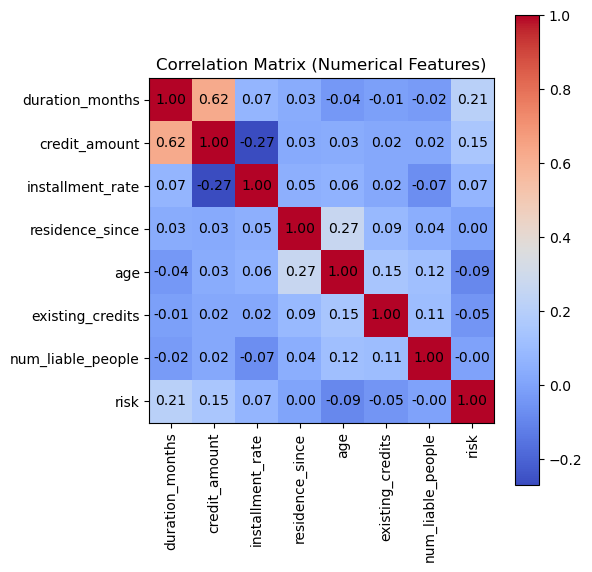

In [87]:
num_features = df.select_dtypes(include=["int64", "float64"]).columns
print(num_features)

correlation_mat = df[num_features].corr()
display(correlation_mat)

plt.figure(figsize=(6, 6))
plt.imshow(correlation_mat, cmap="coolwarm", interpolation="nearest")
for i in range(len(correlation_mat)):
    for j in range(len(correlation_mat)):
        plt.text(i, j, f"{correlation_mat.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')
plt.colorbar()
plt.xticks(range(len(num_features)), num_features, rotation=90)
plt.yticks(range(len(num_features)), num_features)
plt.title("Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_matrix.png")
plt.show()

Strong correlation between duration and credit amount (High credit is taken for longer duration).  
Negative correlation between credit amount and installment rate (Higher credit amount tend to have lower installment rate).

Longer duration may conclude into default

**Cramér’s V**  
Measures strength of association between two categorical variables (0 → no association, 1 → strong).

In [59]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

,checking_account_status,credit_history,purpose,savings_account,employment_since,personal_status_sex,other_debtors,property,other_installment_plans,housing,job,telephone,foreign_worker,risk
checking_account_status,1.000000,0.141812,0.149219,0.175569,0.095318,0.067175,0.108532,0.075764,0.046248,0.098666,0.075182,0.080908,0.079994,0.351740
credit_history,0.141812,1.000000,0.167108,0.071509,0.100715,0.092418,0.087507,0.079820,0.215368,0.097269,0.064852,0.071516,0.070095,0.248378
purpose,0.149219,0.167108,1.000000,0.113819,0.121738,0.151057,0.165262,0.205818,0.143012,0.210169,0.202844,0.220624,0.165990,0.182637
savings_account,0.175569,0.071509,0.113819,1.000000,0.084650,0.062265,0.096510,0.079109,0.021508,0.045151,0.066462,0.093057,0.041079,0.189997
employment_since,0.095318,0.100715,0.121738,0.084650,1.000000,0.166176,0.083182,0.147126,0.070238,0.172929,0.311312,0.150579,0.081646,0.135530
personal_status_sex,0.067175,0.092418,0.151057,0.062265,0.166176,1.000000,0.047437,0.120070,0.058556,0.202165,0.077138,0.089157,0.068194,0.098006
other_debtors,0.108532,0.087507,0.165262,0.096510,0.083182,0.047437,1.000000,0.142079,0.058402,0.059135,0.080447,0.076086,0.120492,0.081519
property,0.075764,0.079820,0.205818,0.079109,0.147126,0.120070,0.142079,1.000000,0.081705,0.553181,0.193905,0.197805,0.142468,0.154012
other_installment_plans,0.046248,0.215368,0.143012,0.021508,0.070238,0.058556,0.058402,0.081705,1.000000,0.089646,0.069423,0.031993,0.043955,0.113310
housing,0.098666,0.097269,0.210169,0.045151,0.172929,0.202165,0.059135,0.553181,0.089646,1.000000,0.127304,0.118284,0.071684,0.134907


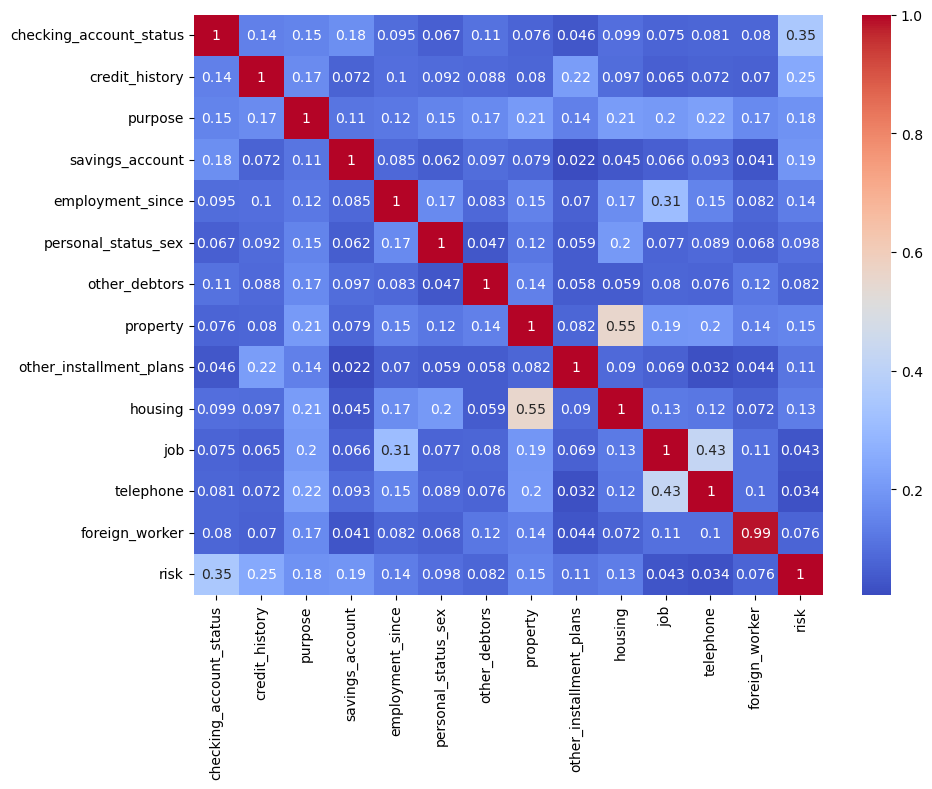

In [91]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.append('risk')
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])
display(cramers_matrix.astype(float))

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix.astype(float), annot=True, cmap="coolwarm")
plt.tight_layout()
plt.savefig("../reports/figures/cramers_v_matrix.png")
plt.show()

Status of Checking account is a strong categorical predictor (Negative/Low balance is an indicator of possibility of default)  
Credit history also plays important role. No credits or successful payment implies low risk  

(Property - Housing) and (Job and Telephone) seem to have moderate to strong association 

### Numerical Feature vs Target (T-test)

In [61]:
from scipy.stats import ttest_ind

num_cols = ['duration_months', 'credit_amount', 'installment_rate',
            'residence_since', 'age', 'existing_credits', 'num_liable_people']

p_values = pd.DataFrame(columns=["Feature", "P value"])

for col in num_cols:
    group_good = df[df['risk'] == 0][col]
    group_bad = df[df['risk'] == 1][col]
    
    stat, p = ttest_ind(group_good, group_bad, equal_var=False)
    p_values = pd.concat([p_values, pd.DataFrame({"Feature": col, "P value": np.round(p, 5)}, index=[0])], ignore_index=True)
    # print(f"{col}: p-value = {p:.5f}")
display(p_values)

,Feature,P value
0,duration_months,0.00000
1,credit_amount,0.00002
2,installment_rate,0.02034
3,residence_since,0.92498
4,age,0.00379
5,existing_credits,0.14161
6,num_liable_people,0.92399


### Categorical Feature vs Target (Chi-Square Test)

In [62]:
from scipy.stats import chi2_contingency

cat_cols = ['checking_account_status', 'credit_history', 'purpose',
            'savings_account', 'employment_since', 'personal_status_sex',
            'other_debtors', 'property', 'other_installment_plans',
            'housing', 'job', 'telephone', 'foreign_worker']

chi_results = pd.DataFrame(columns=["Feature", "P value"])

for col in cat_cols:
    table = pd.crosstab(df[col], df['risk'])
    chi2, p, dof, expected = chi2_contingency(table)
    
    chi_results = pd.concat([chi_results, pd.DataFrame({"Feature": col, "P value": np.round(p, 5)}, index=[0])], ignore_index=True)
    # print(f"{col}: p-value = {p:.5f}")
display(chi_results)

,Feature,P value
0,checking_account_status,0.00000
1,credit_history,0.00000
2,purpose,0.00012
3,savings_account,0.00000
4,employment_since,0.00105
5,personal_status_sex,0.02224
6,other_debtors,0.03606
7,property,0.00003
8,other_installment_plans,0.00163
9,housing,0.00011


### Effect Size for Categorical features (Cramér’s V)

In [63]:
pd.DataFrame(cramers_matrix["risk"].items(), columns=["Feature", "Cramer's V"])

,Feature,Cramer's V
0,checking_account_status,0.351740
1,credit_history,0.248378
2,purpose,0.182637
3,savings_account,0.189997
4,employment_since,0.135530
5,personal_status_sex,0.098006
6,other_debtors,0.081519
7,property,0.154012
8,other_installment_plans,0.113310
9,housing,0.134907


# EDA Summary

## 1. Numerical Features Analysis (T-test)

### Significant Features (p < 0.05)

- **duration_months** (p = 0.00000)  
  -> Strong evidence of difference between Good and Bad customers  
  -> Longer duration loans are associated with higher default risk  

- **credit_amount** (p = 0.00002)  
  -> Higher loan amounts increase default risk  

- **installment_rate** (p = 0.02034)  
  -> Statistically significant but weak practical impact  

- **age** (p = 0.00379)  
  -> Younger customers are slightly more likely to default  

---

### Not Significant (p ≥ 0.05)

- **residence_since** (p = 0.92498)  
- **existing_credits** (p = 0.14161)  
- **num_liable_people** (p = 0.92399)  

-> No statistical evidence of relationship with risk  

---

### Conclusion (Numerical)
- Strong predictors: `duration_months`, `credit_amount`  
- Moderate: `age`, `installment_rate`  
- Weak/irrelevant: `residence_since`, `num_liable_people`

---

## 2. Categorical Features Analysis (Chi-Square Test)

### Strongly Significant Features (p ≈ 0)

- `checking_account_status`
- `credit_history`
- `savings_account`
- `property`

-> Strong dependency with target variable  

---

### Moderately Significant Features

- `purpose` (p = 0.00012)
- `housing` (p = 0.00011)
- `employment_since` (p = 0.00105)
- `other_installment_plans` (p = 0.00163)

-> Clearly relevant features  

---

### Weak but Significant

- `personal_status_sex` (p = 0.02224)
- `other_debtors` (p = 0.03606)
- `foreign_worker` (p = 0.01583)

-> Statistically significant but weaker association  

---

### Not Significant

- `job` (p = 0.59658)
- `telephone` (p = 0.27888)

-> No statistical relationship with target  

---

## 3. Categorical Feature Strength (Cramér’s V)

### Strong Association (V ≥ 0.25)

- **checking_account_status** (V = 0.35) -> strongest predictor  
- **credit_history** (V = 0.25) -> strong predictor  

---

### Moderate Association (0.15 – 0.25)

- `savings_account` (V = 0.19)  
- `purpose` (V = 0.18)  
- `property` (V = 0.15)  

---

### Weak Association (0.08 – 0.15)

- `employment_since` (V = 0.13)  
- `housing` (V = 0.13)  
- `other_installment_plans` (V = 0.11)  

---

### Very Weak / Negligible (< 0.08)

- `personal_status_sex` (V = 0.098)  
- `other_debtors` (V = 0.081)  
- `foreign_worker` (V = 0.076)  
- `job` (V = 0.043)  
- `telephone` (V = 0.034)  

---

## 4. Combined Insights

- Categorical features such as **checking_account_status (V = 0.35)** and **credit_history (V = 0.25)** show the strongest relationship with risk.
- Numerical features like **duration_months (p = 0.00000)** and **credit_amount (p = 0.00002)** are statistically significant but generally weaker predictors.
- Several features such as **job, telephone, residence_since, and num_liable_people** show no statistical significance and can be considered for removal.

---

## 5. Final Feature Categorization

### Strong Predictors
- checking_account_status  
- credit_history  
- duration_months  
- credit_amount  

### Moderate Predictors
- savings_account  
- purpose  
- property  
- age  

### Weak Predictors
- employment_since  
- housing  
- installment_rate  

### Low / No Predictive Value
- job  
- telephone  
- residence_since  
- num_liable_people  

---

## 6. Key Takeaway

- **p-values** were used to determine statistical significance  
- **Cramér’s V** was used to measure strength of association  
- The dataset shows that **categorical behavioral features dominate prediction**, while numerical features provide supporting signal  

---